In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

# Load Data

In [4]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [ ]:
#Total Running Effects
EFFECTS_RUNNING = "2608_effects_running.zarr"

In [7]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
effect_running = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_RUNNING), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Forecast Comparison

In [89]:
era5_running = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/2606to08_era5_running_adj.zarr")
era5_running_ir = isku_utils.grid_to_ir(era5_running, savefile = None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [99]:
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))
forecast_ir = isku_utils.grid_to_ir(forecast, savefile = None)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:33: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [92]:
def grid_avg(ds, dims = ["lat", "lon"]):
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"

    ds_weighted = ds.weighted(weights).mean(dim=dims)
    return ds_weighted

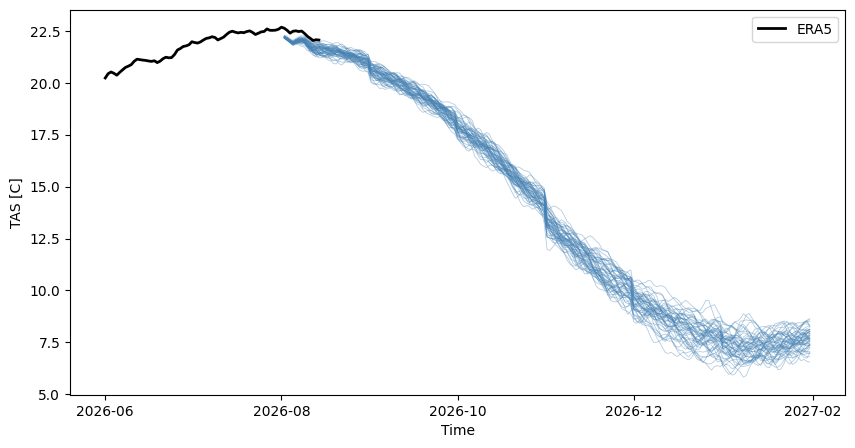

In [97]:
ds_era5 = grid_avg(analysis_utils.land_only(era5_running))-273.15
ds_forecast = grid_avg(analysis_utils.land_only(forecast)).sortby('time')-273.15
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_forecast.time, ds_forecast['tas'].transpose("time", "number"),
        color="steelblue", linewidth=0.6, alpha=0.4)

ax.plot(ds_era5.time, ds_era5['tas'], color="black", linewidth=2.0, label="ERA5")

ax.set_xlabel("Time")
ax.set_ylabel('TAS [C]')
ax.legend()

In [ ]:
diff = (era5_running_ir-forecast_ir.mean(dim = 'number')).mean(dim = 'time')
_polygons_diff = analysis_utils.xarray_to_gpd(diff['tas'], _polygons)

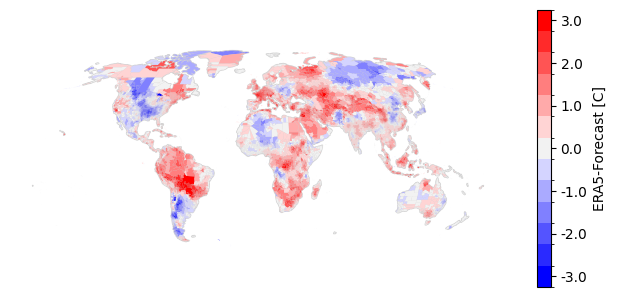

In [127]:
ax = analysis_utils.plot_single(
    _polygons_diff,
    col='tas',
    n_colors = 11,
    cm = 'bwr',
    sup_title=f"",
    cbar_label= 'ERA5-Forecast [C]',
)

fig = ax.figure
fig.savefig("2608_diff_running_total_aug2_14.png", dpi = 600, bbox_inches="tight")

# Mortality Impact

In [67]:
impact = analysis_utils.compute_impact(effect_running, socioeconomics, ensemble = True, 
                                       baseline_period=baseline_period, 
                                       hotonly = "hotonly", rate = False, age_weight = True,
                                       chunks = {'sample': -1,'region': 'auto' })

In [68]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['sample']), _polygons)

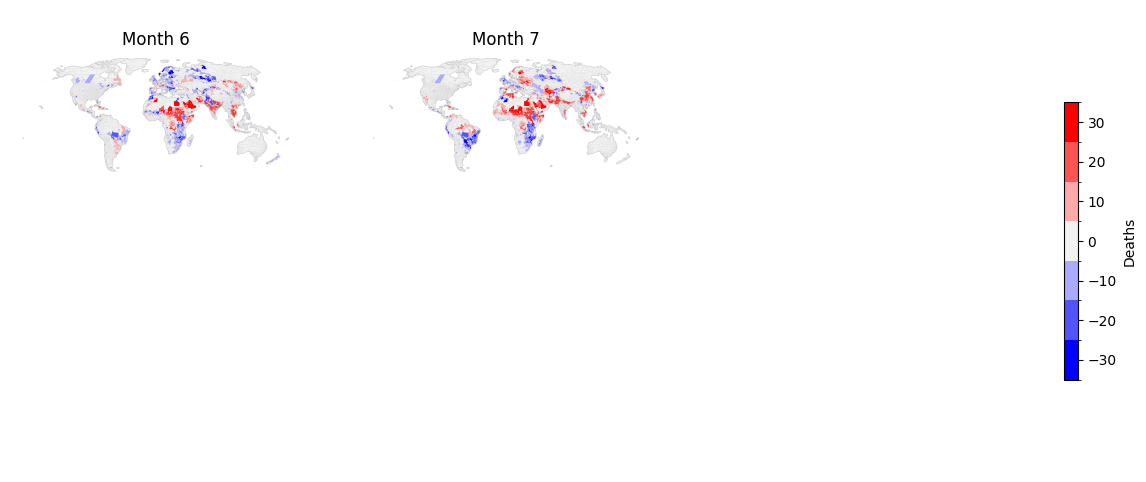

In [20]:
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    sup_title=f"",
    cbar_label= impact.units,
    month_order= [6, 7]
)

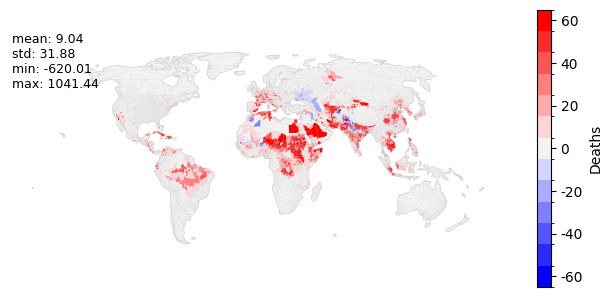

In [69]:
annotation = analysis_utils.build_stats_text(impact.mean(dim = ['sample']).sum(dim = "month"))
fig = analysis_utils.plot_aggregate(
    _polygons_impact,
    col='age_weighted_impact',
    agg = 'sum',
    n_colors = 11,
    cm = 'bwr',
    sup_title=f"",
    annotation = annotation,
    cbar_label= impact.units,
)

fig.savefig("2608_hotonly_running_total_agg.png", dpi = 600, bbox_inches="tight")

In [33]:
_polygons_impact.sort_values(by = 'age_weighted_impact', ascending = False)

,region,gadmid,color,ISO,AREA,PERIMETER,geometry,month,year,age_weighted_impact
14509,CHN.3.19.93,34621,7262,CHN,0.085046,2.013259,"POLYGON ((9645664.576 3196345.95, 9650353.064 ...",7,2026,1036.795422
17549,CHN.27.275.1878,36141,8782,CHN,0.128505,1.972049,"POLYGON ((9436494.776 3305243.953, 9442123.964...",7,2026,1026.628076
17613,CHN.27.291.2013,36173,8814,CHN,0.173247,2.113571,"POLYGON ((9580522.309 3249584.07, 9578313.957 ...",7,2026,607.949487
17527,CHN.27.286.1984,36130,8771,CHN,0.238890,2.281323,"POLYGON ((9595625.474 3324084.348, 9602341.743...",7,2026,441.481229
17167,CHN.12.121.832,35950,8591,CHN,0.232841,2.627149,"POLYGON ((10052066.629 3526237.447, 10060984.8...",7,2026,424.722262
...,...,...,...,...,...,...,...,...,...,...
6218,IND.29.439.1743,85961,3112,IND,0.072153,1.354491,"POLYGON ((6908910.806 2889995.53, 6916721.778 ...",6,2026,-306.921380
6954,IND.10.121.371,86331,3482,IND,0.138999,1.689159,"POLYGON ((7028470.82 3083969.066, 7027070.95 3...",6,2026,-313.685777
34400,PAK.7.21.85,120613,17214,PAK,0.839524,5.595411,"POLYGON ((6599431.193 3398196.746, 6593275.398...",6,2026,-329.646631
34408,PAK.7.23.96,120617,17218,PAK,0.175308,1.853400,"POLYGON ((6725554.2 3384928.207, 6730907.946 3...",6,2026,-684.388210


# Comparison of Impacts Jun-Dec

In [128]:
impact_running = analysis_utils.compute_impact(effect_running, socioeconomics, ensemble = True, 
                                       baseline_period=baseline_period, 
                                       hotonly = "hotonly", rate = False, age_weight = True,
                                       chunks = {'sample': -1,'region': 'auto' })

impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, 
                                       baseline_period=baseline_period, 
                                       hotonly = "hotonly", rate = False, age_weight = True,
                                       chunks = {'sample': -1,'region': 'auto' })

Text(0, 0.5, 'Total Deaths')

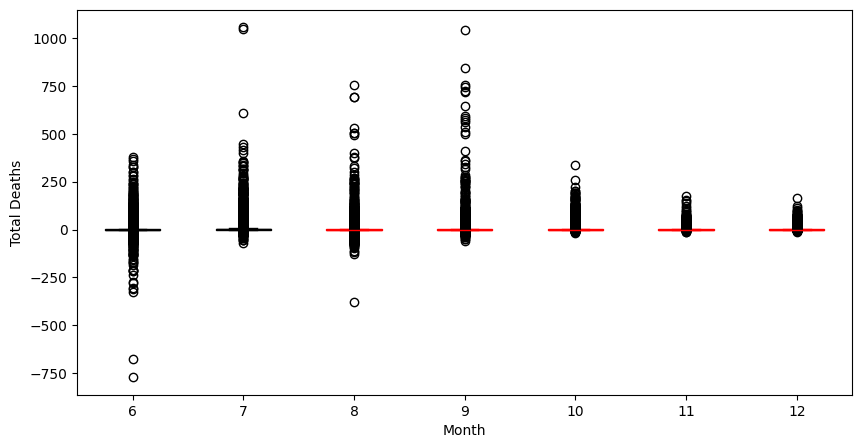

In [142]:
combined = xr.concat([impact_running.mean(dim = ['sample']), impact.mean(dim = ['number', 'sample'])], dim="month")

data_by_month = [combined.sel(month = m).values.flatten() for m in range(6, 13)]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_month, positions=range(6, 13), tick_labels=range(6, 13), patch_artist=True)

colors = ["black", "black", "red", "red", "red", "red", "red"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)

for element in ["whiskers", "caps", "medians"]:
    for i, item in enumerate(bp[element]):
        color = colors[i // 2] if element in ("whiskers", "caps") else colors[i]
        item.set_color(color)
ax.set_xlabel("Month")
ax.set_ylabel("Total Deaths")

(-10.0, 10.0)

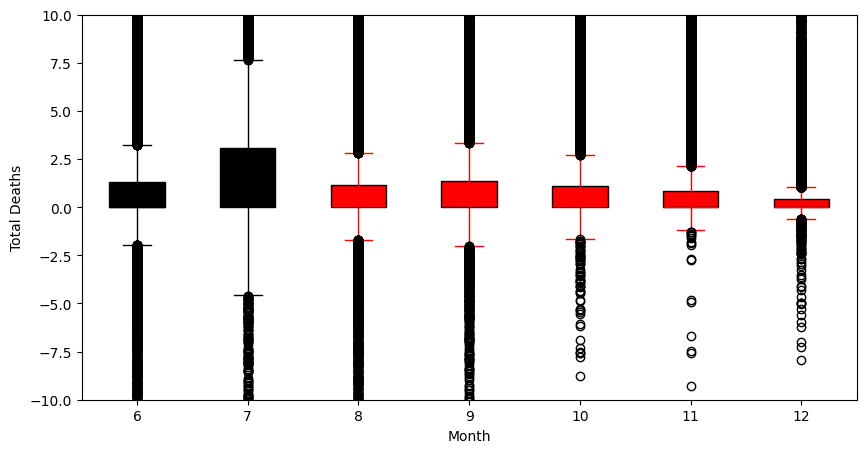

In [144]:
combined = xr.concat([impact_running.mean(dim = ['sample']), impact.mean(dim = ['number', 'sample'])], dim="month")

data_by_month = [combined.sel(month = m).values.flatten() for m in range(6, 13)]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data_by_month, positions=range(6, 13), tick_labels=range(6, 13), patch_artist=True)

colors = ["black", "black", "red", "red", "red", "red", "red"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

for element in ["whiskers", "caps", "medians"]:
    for i, item in enumerate(bp[element]):
        color = colors[i // 2] if element in ("whiskers", "caps") else colors[i]
        item.set_color(color)
ax.set_xlabel("Month")
ax.set_ylabel("Total Deaths")
ax.set_ylim(-10, 10)